# Data Cleaning: MCO vs MIA Analysis

Cleans filtered data and creates derived columns for analysis.

## Setup

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
print(f"pandas {pd.__version__}")

pandas 2.1.4


### Plots style definition

In [26]:
# Set style
sns.set_style("whitegrid")
sns.set_palette("husl")  # or "Set2", "pastel", "muted"
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'

## Load Data

In [10]:
# Load combined data from notebook 01
df = pd.read_csv('../data/processed/mco_mia_2004_2008.csv.gz', low_memory=False)

print(f"Loaded {len(df):,} rows")
print(f"Years: {df['Year'].min()}-{df['Year'].max()}")
print(f"Columns: {len(df.columns)}")

display(df.head())

Loaded 1,592,198 rows
Years: 2004-2008
Columns: 29


,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2004,1,1,4,1622.0,1625,1955.0,2003,UA,470,N501UA,153.0,158.0,128.0,-8.0,-3.0,ORD,MCO,1005,2.0,23.0,0,NaN,0,0.0,0.0,0.0,0.0,0.0
1,2004,1,2,5,1641.0,1625,2033.0,2003,UA,470,N514UA,172.0,158.0,123.0,30.0,16.0,ORD,MCO,1005,2.0,47.0,0,NaN,0,0.0,0.0,14.0,0.0,16.0
2,2004,1,3,6,1644.0,1625,2000.0,2003,UA,470,N504UA,136.0,158.0,120.0,-3.0,19.0,ORD,MCO,1005,3.0,13.0,0,NaN,0,0.0,0.0,0.0,0.0,0.0
3,2004,1,4,7,1744.0,1625,2144.0,2003,UA,470,N558UA,180.0,158.0,128.0,101.0,79.0,ORD,MCO,1005,4.0,48.0,0,NaN,0,12.0,0.0,22.0,0.0,67.0
4,2004,1,5,1,1637.0,1625,2006.0,2003,UA,470,N525UA,149.0,158.0,131.0,3.0,12.0,ORD,MCO,1005,4.0,14.0,0,NaN,0,0.0,0.0,0.0,0.0,0.0


## Data Cleaning

In [46]:
# Create flight date
df['FlightDate'] = pd.to_datetime(
    df[['Year', 'Month', 'DayofMonth']].rename(columns={'DayofMonth': 'Day'}),
    errors='coerce'
)

# Split time columns into hours and minutes
for time_col in ['CRSDepTime', 'DepTime', 'CRSArrTime', 'ArrTime']:
    df[f'{time_col}_Hour'] = (df[time_col] // 100).astype('Int64')
    df[f'{time_col}_Min'] = (df[time_col] % 100).astype('Int64')

# On-time performance (within 15 minutes)
df['OnTime'] = (df['ArrDelay'].fillna(999) <= 15) & (df['Cancelled'] == 0)

# Delay categories
df['DelayCategory'] = pd.cut(
    df['ArrDelay'],
    bins=[-np.inf, 0, 15, 60, np.inf],
    labels=['Early', 'OnTime', 'Delayed', 'SeverelyDelayed']
)

# Time features
df['Quarter'] = df['Month'].apply(lambda m: (m-1)//3 + 1)
df['IsHolidaySeason'] = df['Month'].isin([6, 7, 8, 11, 12])

# Day names
day_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
df['DayName'] = df['DayOfWeek'].map(day_map)

# Airport indicators
df['IsMCO'] = (df['Origin'] == 'MCO') | (df['Dest'] == 'MCO')
df['IsMIA'] = (df['Origin'] == 'MIA') | (df['Dest'] == 'MIA')

# 1. Flight direction (departing vs arriving at MCO/MIA)
df['MCO_Direction'] = df.apply(lambda x: 'Departure' if x['Origin'] == 'MCO' 
                                else ('Arrival' if x['Dest'] == 'MCO' else None), axis=1)
df['MIA_Direction'] = df.apply(lambda x: 'Departure' if x['Origin'] == 'MIA' 
                                else ('Arrival' if x['Dest'] == 'MIA' else None), axis=1)

# 2. Time of day categories (useful for delay patterns)
df['TimeOfDay'] = pd.cut(df['CRSDepTime_Hour'], 
                          bins=[0, 6, 12, 18, 24],
                          labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                          include_lowest=True)

# 3. Weekend indicator
df['IsWeekend'] = df['DayOfWeek'].isin([6, 7])

# 4. Distance categories
df['DistanceCategory'] = pd.cut(df['Distance'],
                                 bins=[0, 500, 1000, 2000, 5000],
                                 labels=['Short', 'Medium', 'Long', 'VeryLong'])

# 5. Season
df['Season'] = df['Month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                 3: 'Spring', 4: 'Spring', 5: 'Spring',
                                 6: 'Summer', 7: 'Summer', 8: 'Summer',
                                 9: 'Fall', 10: 'Fall', 11: 'Fall'})

# 6. Primary delay cause (for flights with delays)
delay_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
df['PrimaryDelayCause'] = df[delay_cols].idxmax(axis=1)
df.loc[df['ArrDelay'] <= 0, 'PrimaryDelayCause'] = 'None'

print("Created derived columns")
df.head()

Created derived columns


/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_71040/812337212.py:62: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df['PrimaryDelayCause'] = df[delay_cols].idxmax(axis=1)


,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,FlightDate,OnTime,DelayCategory,Quarter,IsHolidaySeason,DayName,IsMCO,IsMIA,DepHour,DepMinute,ArrHour,ArrMinute,CRSDepTime_Hour,CRSDepTime_Min,DepTime_Hour,DepTime_Min,CRSArrTime_Hour,CRSArrTime_Min,ArrTime_Hour,ArrTime_Min,MCO_Direction,MIA_Direction,TimeOfDay,IsWeekend,DistanceCategory,Season,PrimaryDelayCause
0,2004,1,1,4,1622.0,1625,1955.0,2003,UA,470,N501UA,153.0,158.0,128.0,-8.0,-3.0,ORD,MCO,1005,2.0,23.0,0,NaN,0,0.0,0.0,0.0,0.0,0.0,2004-01-01,True,Early,1,False,Thu,True,False,16,22.0,19,55.0,16,25,16,22,20,3,19,55,Arrival,None,Afternoon,False,Long,Winter,None
1,2004,1,2,5,1641.0,1625,2033.0,2003,UA,470,N514UA,172.0,158.0,123.0,30.0,16.0,ORD,MCO,1005,2.0,47.0,0,NaN,0,0.0,0.0,14.0,0.0,16.0,2004-01-02,False,Delayed,1,False,Fri,True,False,16,41.0,20,33.0,16,25,16,41,20,3,20,33,Arrival,None,Afternoon,False,Long,Winter,LateAircraftDelay
2,2004,1,3,6,1644.0,1625,2000.0,2003,UA,470,N504UA,136.0,158.0,120.0,-3.0,19.0,ORD,MCO,1005,3.0,13.0,0,NaN,0,0.0,0.0,0.0,0.0,0.0,2004-01-03,True,Early,1,False,Sat,True,False,16,44.0,20,0.0,16,25,16,44,20,3,20,0,Arrival,None,Afternoon,True,Long,Winter,None
3,2004,1,4,7,1744.0,1625,2144.0,2003,UA,470,N558UA,180.0,158.0,128.0,101.0,79.0,ORD,MCO,1005,4.0,48.0,0,NaN,0,12.0,0.0,22.0,0.0,67.0,2004-01-04,False,SeverelyDelayed,1,False,Sun,True,False,17,44.0,21,44.0,16,25,17,44,20,3,21,44,Arrival,None,Afternoon,True,Long,Winter,LateAircraftDelay
4,2004,1,5,1,1637.0,1625,2006.0,2003,UA,470,N525UA,149.0,158.0,131.0,3.0,12.0,ORD,MCO,1005,4.0,14.0,0,NaN,0,0.0,0.0,0.0,0.0,0.0,2004-01-05,True,OnTime,1,False,Mon,True,False,16,37.0,20,6.0,16,25,16,37,20,3,20,6,Arrival,None,Afternoon,False,Long,Winter,CarrierDelay


## Data Summary

In [12]:
print(f"Total flights: {len(df):,}")
print(f"Date range: {df['FlightDate'].min().date()} to {df['FlightDate'].max().date()}")
print(f"Cancellation rate: {(df['Cancelled'].sum()/len(df))*100:.2f}%")

# On-time performance (exclude cancelled flights)
non_cancelled = df[df['Cancelled'] == 0]
otp_rate = (non_cancelled['OnTime'].sum() / len(non_cancelled)) * 100
avg_delay = non_cancelled['ArrDelay'].mean()

print(f"On-time performance: {otp_rate:.2f}%")
print(f"Average delay: {avg_delay:.1f} minutes")

print("\nFlights by year:")
print(df['Year'].value_counts().sort_index())

Total flights: 1,592,198
Date range: 2004-01-01 to 2008-04-30
Cancellation rate: 1.22%
On-time performance: 78.25%
Average delay: 8.3 minutes

Flights by year:
Year
2004    344250
2005    364415
2006    365595
2007    384594
2008    133344
Name: count, dtype: int64


## Airport Comparison

In [13]:
# Departures by airport
mco_departures = len(df[df['Origin'] == 'MCO'])
mia_departures = len(df[df['Origin'] == 'MIA'])

print(f"MCO departures: {mco_departures:,}")
print(f"MIA departures: {mia_departures:,}")

# On-time performance by airport
mco_otp = df[df['Origin'] == 'MCO']['OnTime'].mean() * 100
mia_otp = df[df['Origin'] == 'MIA']['OnTime'].mean() * 100

print(f"\nMCO OTP: {mco_otp:.2f}%")
print(f"MIA OTP: {mia_otp:.2f}%")

MCO departures: 521,651
MIA departures: 283,825

MCO OTP: 78.88%
MIA OTP: 74.03%


## Save Cleaned Data

In [ ]:
output_path = '../data/processed/mco_mia_clean.csv.gz'
df.to_csv(output_path, index=False, compression='gzip')

print(f"Saved {len(df):,} rows to {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1024**2:.1f} MB")

## Visualizations

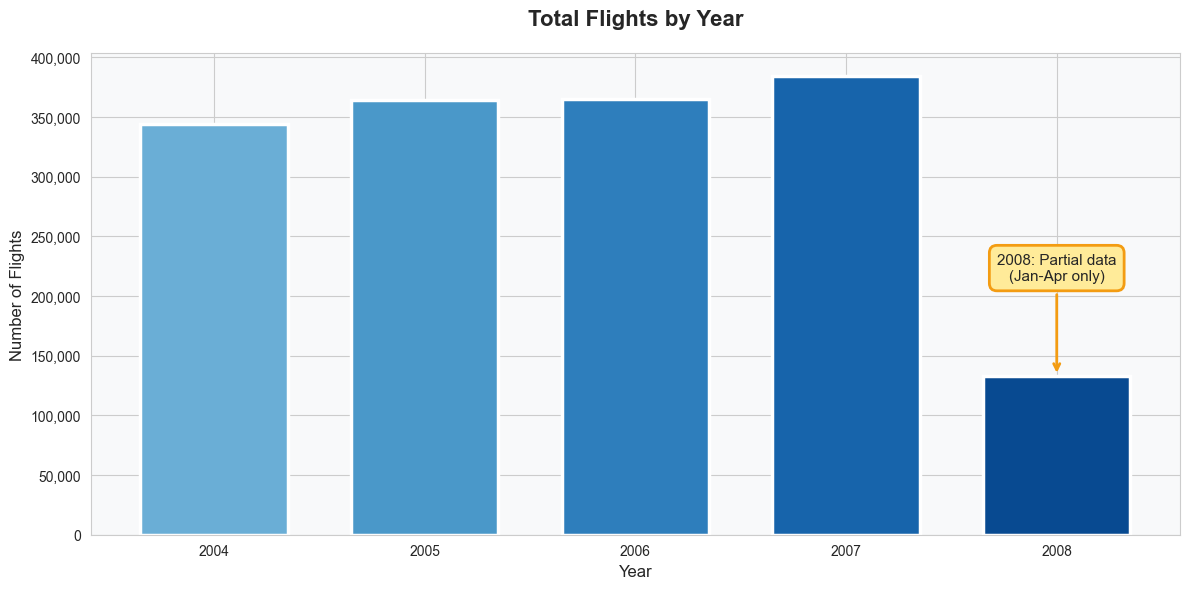

In [38]:
# Annual flight volume
yearly_counts = df['Year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))

# Create bars with gradient colors
colors = plt.cm.Blues(np.linspace(0.5, 0.9, len(yearly_counts)))
bars = ax.bar(yearly_counts.index, yearly_counts.values, color=colors, 
              edgecolor='white', linewidth=2.5, width=0.7)

# Round the bar corners
for bar in bars:
    bar.set_capstyle('round')

ax.set_title('Total Flights by Year', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Flights', fontsize=12)
ax.set_xticks(yearly_counts.index)

# Format y-axis with thousands separator
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Add annotation above 2008 bar
ax.annotate('2008: Partial data\n(Jan-Apr only)',
            xy=(2008, yearly_counts[2008]),
            xytext=(2008, yearly_counts[2008] + 80000),
            fontsize=11,
            ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffeb99', edgecolor='#f39c12', linewidth=2),
            arrowprops=dict(arrowstyle='->', lw=2, color='#f39c12'))

plt.tight_layout()
plt.show()

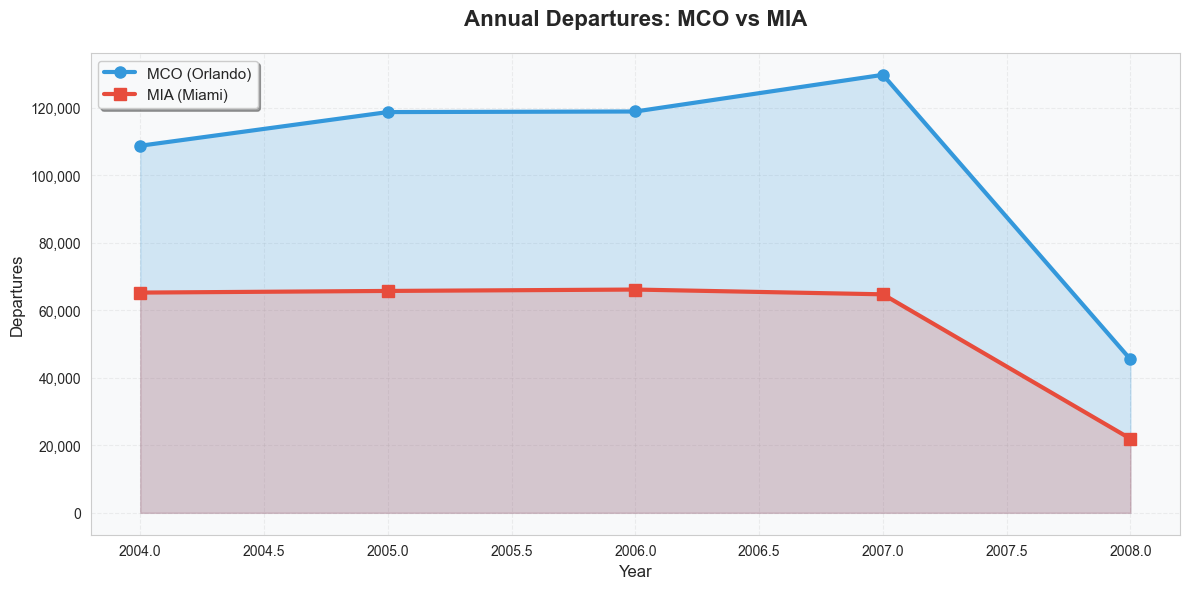

In [28]:
# MCO vs MIA departures over time
mco_yearly = df[df['Origin'] == 'MCO'].groupby('Year').size()
mia_yearly = df[df['Origin'] == 'MIA'].groupby('Year').size()

fig, ax = plt.subplots(figsize=(12, 6))

# Define colors
mco_color = '#3498db'  # Blue
mia_color = '#e74c3c'  # Red

# Plot with filled areas
ax.fill_between(mco_yearly.index, mco_yearly.values, alpha=0.2, color=mco_color)
ax.fill_between(mia_yearly.index, mia_yearly.values, alpha=0.2, color=mia_color)

# Plot lines with markers
ax.plot(mco_yearly.index, mco_yearly.values, marker='o', markersize=8, 
        label='MCO (Orlando)', linewidth=3, color=mco_color)
ax.plot(mia_yearly.index, mia_yearly.values, marker='s', markersize=8, 
        label='MIA (Miami)', linewidth=3, color=mia_color)

ax.set_title('Annual Departures: MCO vs MIA', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Departures', fontsize=12)

# Format y-axis with thousands separator
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

ax.legend(fontsize=11, frameon=True, shadow=True, loc='upper left')
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

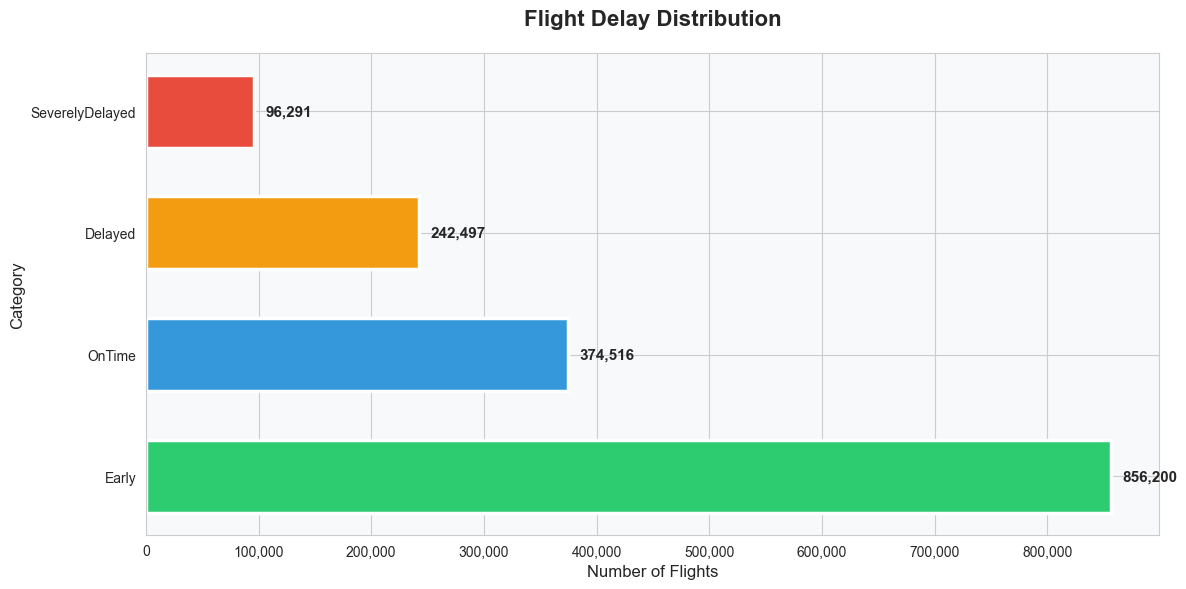

In [29]:
# Delay distribution
delay_counts = df['DelayCategory'].value_counts()

# Sort by logical order (best to worst)
order = ['Early', 'OnTime', 'Delayed', 'SeverelyDelayed']
delay_counts = delay_counts.reindex(order)

# Semantic colors (green -> blue -> orange -> red)
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 6))

# Create horizontal bars
bars = ax.barh(delay_counts.index, delay_counts.values, color=colors, 
               edgecolor='white', linewidth=2.5, height=0.6)

# Round the bar corners
for bar in bars:
    bar.set_capstyle('round')

# Add value labels on bars
for i, (category, value) in enumerate(delay_counts.items()):
    ax.text(value + 10000, i, f'{value:,}', va='center', fontsize=11, fontweight='bold')

ax.set_title('Flight Delay Distribution', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Flights', fontsize=12)
ax.set_ylabel('Category', fontsize=12)

# Format x-axis with thousands separator
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## Next Steps

Data is ready for:
- Detailed analysis
- Additional visualizations
- Power BI/Tableau dashboards